In [6]:
import pandas as pd

In [24]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
stk_data=pd.read_csv("Tatacoffee13_21.csv",parse_dates=['Date'],index_col='Date')

In [10]:
stk_data

,Open,High,Low,Close
Date,,,,
2013-01-01,1410.60,1427.90,1408.30,1415.10
2013-01-02,1421.00,1626.60,1416.15,1607.40
2013-01-03,1632.55,1673.90,1613.05,1626.20
2013-01-04,1627.75,1627.75,1574.60,1579.05
2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...
2021-12-22,202.90,207.80,201.35,205.00
2021-12-23,206.00,206.85,202.05,202.95
2021-12-24,203.90,203.90,199.35,201.00


In [12]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2225 entries, 2013-01-01 to 2021-12-28
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    2225 non-null   float64
 1   High    2225 non-null   float64
 2   Low     2225 non-null   float64
 3   Close   2225 non-null   float64
dtypes: float64(4)
memory usage: 86.9 KB


In [14]:
column="Close"

In [16]:
from sklearn.preprocessing import MinMaxScaler
Ms=MinMaxScaler()
data1=Ms.fit_transform(stk_data[[column]])

In [17]:
training_size=round(len(data1)*0.80)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

1780
X_train length: (1780, 1)
X_test length: (445, 1)
y_train length: (1780, 1)
y_test length: (445, 1)


In [66]:
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
orders=[(0,0,1),(0,0,2)]
from statsmodels.tsa.arima.model import ARIMA
for order in orders:
    for td in trends:
        
            #print(td)
            #trendslist.append(td)
        model = ARIMA(X_train, order=order,trend=td,)
        model_fit = model.fit()
            # make prediction
        y_pred= model_fit.predict(len(X_train), len(data1)-1)
            #print(y_pred)
        from stockFunctions import rmsemape
        print("Order={},Trend={}".format(order,td))
        rmsemape(y_test,y_pred)
        print("************")

Order=(0, 0, 1),Trend=n
RMSE-Testset: 0.06324823015930449
maPe-Testset: 0.9964748373773213
************
Order=(0, 0, 1),Trend=t
RMSE-Testset: 0.08670246462090508
maPe-Testset: 1240182001280.3188
************
Order=(0, 0, 1),Trend=c
RMSE-Testset: 0.16245200988390837
maPe-Testset: 2160951297163.7393
************
Order=(0, 0, 1),Trend=ct
RMSE-Testset: 0.3476445373077362
maPe-Testset: 1880038729790.878
************
Order=(0, 0, 2),Trend=n
RMSE-Testset: 0.06324695011320927
maPe-Testset: 0.9944814705331136
************
Order=(0, 0, 2),Trend=t
RMSE-Testset: 0.08670027234568822
maPe-Testset: 1240161010857.7793
************
Order=(0, 0, 2),Trend=c
RMSE-Testset: 0.16236945295501579
maPe-Testset: 2161860606819.9958
************
Order=(0, 0, 2),Trend=ct
RMSE-Testset: 0.3476445373077362
maPe-Testset: 1880038729790.878
************


In [68]:
td='n'
order=(0, 0, 2)
model = ARIMA(X_train, order=order,trend=td,)
model_fit = model.fit()
    # make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
    #print(y_pred)
from stockFunctions import rmsemape
print("Trend={}".format(td))
rmsemape(y_test,y_pred)
print("************")

Trend=n
RMSE-Testset: 0.06324695011320927
maPe-Testset: 0.9944814705331136
************


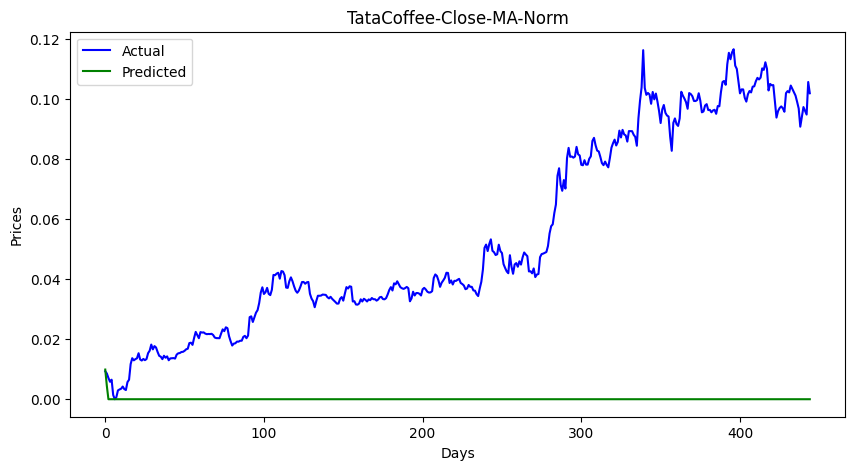

In [70]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-MA-Norm","Days","Prices")

In [72]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [74]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

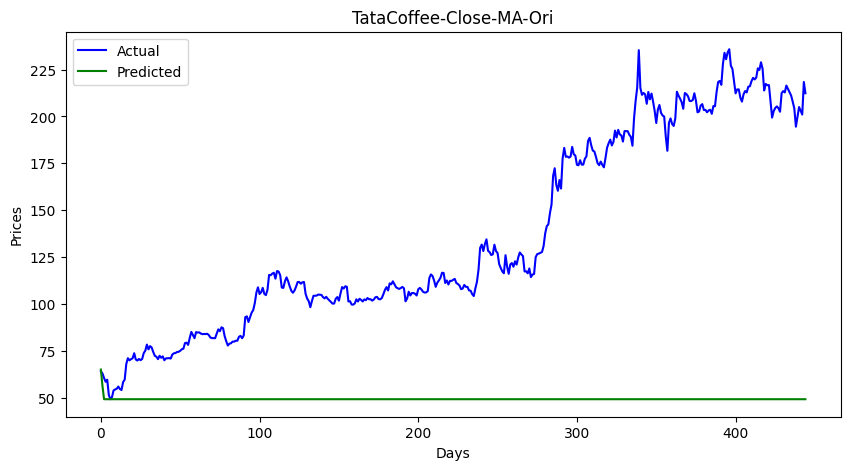

In [76]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-MA-Ori","Days","Prices")

In [78]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 101.11922384099897
maPe-Testset: 0.5765081885216192


In [80]:
forecast=model_fit.predict(len(data1), len(data1)+3)

In [82]:
forecast

array([0., 0., 0., 0.])

In [84]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [86]:
forecast_stock_price_test_oriF

,Closefore
0,49.4
1,49.4
2,49.4
3,49.4


In [88]:
forecast_stock_price_test_oriF.to_csv("CloseMA.csv",index=False)